### Plot all coefficients against the scalar invariants

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

#=====================================================================
ck      = torch.load('2D_sigma_ymasked.pt', weights_only=False)
coeffs  = ck['coeffs']
x_a_raw = ck['x_a_raw']
#======================================================================

N  = coeffs.shape[0]
a0, a1, a2 = coeffs[:,0], coeffs[:,1], coeffs[:,2]
I2_D, eps   = x_a_raw[:,0], x_a_raw[:,1]


def plot_coeff(coeff, coeff_name, x_list, x_names, n_bins=60):
    ncols = len(x_list)
    fig, axes = plt.subplots(2, ncols, figsize=(6*ncols, 8))

    slopes = []
    for j, (x_phys, x_name) in enumerate(zip(x_list, x_names)):
        # always work with absolute values for consistency
        xabs = np.abs(x_phys)
        cabs = np.abs(coeff)

        # ── ROW 0: linear axes, |x| vs |coeff| ─────────────────────────────
        ax = axes[0, j]
        ax.scatter(xabs, cabs, s=2, alpha=0.3, c=eps, rasterized=True)
        ax.set_xlabel(f'|{x_name}|', fontsize=10)
        ax.set_ylabel(f'$|{coeff_name}|$', fontsize=11)
        ax.set_title('Ordinary', fontsize=10)
        ax.grid(True, alpha=0.3)

        # ── ROW 1: log-log axes, same |x| vs |coeff| ───────────────────────
        ax = axes[1, j]
        pos = (xabs > 0) & (cabs > 0)
        xp, cp = xabs[pos], cabs[pos]
        ax.scatter(xp, cp, s=2, alpha=0.3, color='steelblue', rasterized=True)

        # power-law slope
        lx, ly = np.log10(xp), np.log10(cp)
        fin = np.isfinite(lx) & np.isfinite(ly)
        slope = np.nan
        if fin.sum() > 2:
            slope, intercept = np.polyfit(lx[fin], ly[fin], 1)
            xl = np.linspace(lx[fin].min(), lx[fin].max(), 200)
            ax.plot(10**xl, 10**(slope*xl+intercept), 'k--', lw=1.5,
                    label=f'slope={slope:.2f}')
        slopes.append(slope)

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(f'|{x_name}|', fontsize=10)
        ax.set_ylabel(f'$|{coeff_name}|$', fontsize=11)
        ax.set_title('Log-log', fontsize=10)
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=8)

    plt.suptitle(f'$|{coeff_name}|$ vs invariants', fontsize=13)
    return fig, slopes

for coeff, name in zip([a0,a1,a2], ['a_0','a_1','a_2']):
    _, slopes = plot_coeff(coeff, name, [I2_D,eps], [r'$I_{2D}$',r'$\epsilon$'])
    print(f"{name} slopes: I_2D={slopes[0]:.3f} eps={slopes[1]:.3f}")
    plt.show()

print("Done.")

In [ ]:
TIME_START = 35
Y_SLICE    = slice(20, 35)

def load_and_nondim(entry):
    gd = entry["gamma_dot"]
    kn    = 1e5
    dp    = 0.01
    scale = dp / kn
    sig_raw = torch.load(entry["sigma"],   weights_only=False).numpy()
    def_raw = torch.load(entry["deform"],  weights_only=False).numpy()

    T, Gx, Gy, Gz = def_raw.shape[0], 50,38,10
    sig_raw = sig_raw.reshape(T, Gx, Gy, Gz, 3, 3)
    def_raw = def_raw.reshape(T, Gx, Gy, Gz, 3, 3)

    sig_raw = sig_raw[TIME_START:, :, Y_SLICE, :]
    def_raw = def_raw[TIME_START:, :, Y_SLICE, :]
    # eps_raw = eps_raw[TIME_START:, :, Y_SLICE, :]

    p_hydro  = -(sig_raw[..., 0, 0] + sig_raw[..., 1, 1] + sig_raw[..., 2, 2]) / 3.0
    D_dim_2d = def_raw[..., :2, :2].copy()
    sig_2d   = sig_raw[..., :2, :2]
    D_hat    = def_raw[..., :2, :2] / gd                    # non-dimensional D

    T2, Gx2, Gy2, Gz2 = D_hat.shape[:4]
    N = T2 * Gx2 * Gy2 * Gz2

    sigma   = sig_2d.reshape(N, 2, 2)
    stress = sigma*scale
    D_hat   = D_hat.reshape(N, 2, 2)
    D_dim   = D_dim_2d.reshape(N, 2, 2)
    p_hydro = p_hydro.reshape(N)
    # epsilon = eps_raw.reshape(N)

    print(f"  [{entry['tag']}]  N={N:,}  γ̇={gd:.4f}")
    return stress, D_hat, D_dim, p_hydro


In [ ]:
print("Loading datasets...")
#{'014': 0.035, '003': 0.00775, '03': 0.0775,'085': 0.2125, '14': 0.35,}
DATASETS = [
    dict(tag="vf588_vt085", gamma_dot=0.2125,
         sigma  =r"D:\ml_granular\Sparse Modeling\DAY-TAH\CG_stress_Tensor_vf601vt085.pt",
         deform =r"D:\ml_granular\Sparse Modeling\DAY-TAH\deformation_tensorvf601vt085.pt"),
    dict(tag="vf588_vt03", gamma_dot=0.0775,
         sigma  =r"D:\ml_granular\Sparse Modeling\DAY-TAH\CG_stress_Tensor_vf601vt03.pt",
         deform =r"D:\ml_granular\Sparse Modeling\DAY-TAH\deformation_tensorvf601vt03.pt"),
]

sigma_list, D_list, Ddim_list, p_list, eps_list = [], [], [], [], []
#=======================================================================
for entry in DATASETS:
    sig, D_hat, D_dim, p_hyd = load_and_nondim(entry)
    sigma_list.append(sig)
    D_list.append(D_hat)
    Ddim_list.append(D_dim)
    p_list.append(p_hyd)
#=======================================================================
sigma   = np.concatenate(sigma_list,  axis=0)
D       = np.concatenate(D_list,      axis=0)
D_dim   = np.concatenate(Ddim_list,   axis=0)

Loading datasets...
  [vf588_vt085]  N=382,500  γ̇=0.2125
  [vf588_vt03]  N=322,500  γ̇=0.0775


(705000, 2, 2)

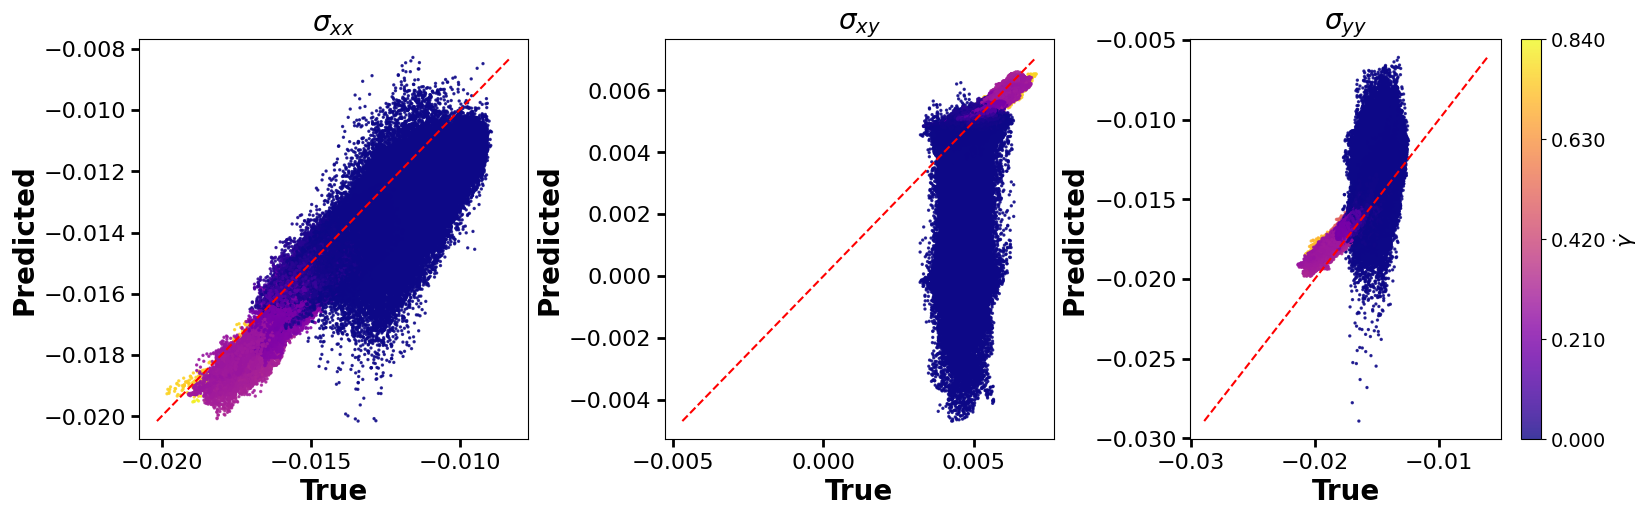

σ_xx  RMSE=0.00  R²=0.8565
σ_xy  RMSE=0.00  R²=-16.4732
σ_yy  RMSE=0.00  R²=0.0303


In [ ]:
# Load trained coefficients
ck     = torch.load('2D_sigma_ymasked.pt', weights_only=False)
coeffs = ck['coeffs']          # (N_train, 3)  → a0, a1, a2 per training point
# Reconstruct y-indices for validation data
N = len(D)
T_val  = len(D) // (50 * 15 * 10)
y_idx  = np.tile(np.arange(15), T_val * 50 * 10)   # repeating y-index for each point
# but need correct reshape order matching (T,Gx,Gy,Gz).reshape(N)
y_idx  = np.broadcast_to(
             np.arange(15)[None, None, :, None],
             (T_val, 50, 15, 10)
         ).reshape(-1)                               # (N,)

y_idx_s1 = y_idx[N//2:]
gamma_dot_local = np.sqrt(2.0 * np.einsum('nij,nij->n', D_dim, D_dim))
gamma_dot_s1 = gamma_dot_local[N//2:]
# ── Build basis tensors for validation data ──
N      = len(D)
I_mat  = np.eye(2)[None].repeat(N, axis=0)          # (N,2,2)
D2_mat = np.einsum('nij,njk->nik', D, D)            # D̂^2 (N,2,2)

# ── Predict ──
sigma_pred = (a0[:, None, None] * I_mat
            + a1[:, None, None] * D
            + a2[:, None, None] * D2_mat)   # (N,2,2)

s1 = sigma[N//2:]
s1_pred = sigma_pred[N//2:]

# ── Parity plots ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
comps = [('xx', 0, 0), ('xy', 0, 1), ('yy', 1, 1)]
for ax, (lbl, i, j) in zip(axes.flat, comps):
    yt = s1[:, i, j]
    yp = s1_pred[:, i, j]
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    r2 = 1 - np.var(yt - yp) / np.var(yt)

    sc = ax.scatter(yt, yp, s=2, alpha=0.8, rasterized=True,
                    c=gamma_dot_s1, cmap='plasma')
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_title(f'$\\sigma_{{{lbl}}}$', fontsize=20, fontweight='bold')
    ax.set_xlabel('True',      fontsize=20, fontweight='bold')
    ax.set_ylabel('Predicted', fontsize=20, fontweight='bold')
    ax.tick_params(axis='both', labelsize=16, width=2, length=6)

fig.subplots_adjust(left=0.08, right=0.88, top=0.95, bottom=0.15, wspace=0.35)
cbar = fig.colorbar(sc)
cbar.set_label(r'$\dot{\gamma}$', fontsize=16, fontweight='bold')

# y_min, y_max = y_idx_s1.min(), y_idx_s1.max()
# display_min, display_max = 5, 35               # what you want to show
# ticks_data = np.linspace(y_min, y_max, 10)
# ticks_display = np.interp(ticks_data, [y_min, y_max], [display_min, display_max])

# # Set ticks using DATA space values, but label with DISPLAY space
# cbar.set_ticks(ticks_data)
# cbar.set_ticklabels([f'{int(t)}' for t in ticks_display])
# cbar.ax.tick_params(labelsize=14)
ticks_gamma = np.linspace(gamma_dot_s1.min(), gamma_dot_s1.max(), 5)
cbar.set_ticks(ticks_gamma)                              # ← Set tick positions
cbar.set_ticklabels([f'{t:.3f}' for t in ticks_gamma])  # ← Set labels for each tick
cbar.ax.tick_params(labelsize=14)

plt.show()
# ── Error summary ──
for lbl, i, j in comps:
    yt   = s1[:, i, j]
    yp   = s1_pred[:, i, j]
    rmse = np.sqrt(np.mean((yt - yp)**2))
    r2   = 1 - np.var(yt - yp) / np.var(yt)
    print(f"σ_{lbl}  RMSE={rmse:.2f}  R²={r2:.4f}")

In [71]:
s1.mean(axis = 0), s1_pred.mean(axis = 0)

(array([[-0.01809971,  0.00647558],
        [ 0.00647558, -0.01963761]]),
 array([[-0.01414336,  0.00731513],
        [ 0.00731513, -0.01419121]]))